# 06 — Evaluation inspection

Pure inspection of an ablation study run. No orchestration here: phases are run via `scripts/run_evaluation_phase.py` and the rollup via `scripts/run_evaluation_rollup.py`. This notebook only **reads** MLflow artifacts and renders comparisons.

Set `ABLATION_ID` in the next cell to the value printed by the phase scripts.

## 1. Setup

In [31]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from mlflow.tracking import MlflowClient

from src.tracking import setup_tracking_uri
from src.evaluation.sample import load_eval_sample
from src.evaluation.metrics import check_format_adherence
from src.evaluation.plot_style import (
    apply_style, grouped_bar, style_axes, labels_for, metric_title,
    ACCENT, ACCENT_WARM, CONFIG_COLORS,
)

# Shared thesis-quality figure style (same palette as the rollup figures).
apply_style()

# Canonical ablation run. NOTE: the id string is the original 2026-06-15 timestamp,
# but this tag now groups the *re-scored* phase-1 (post-RAGAS-fix, 15:30) and the
# *re-run* phase-2 (FT GGUF re-converted, 06-16) children + rollup — i.e. the good
# data, not the discarded 0814 collapse run. See DECISIONS.md (2026-06-16).
ABLATION_ID = "2026-06-15T0814"
EXPERIMENT = "tfm-evaluation"
CONFIG_ORDER = ["A_base", "B_finetuned", "C_base_rag", "D_finetuned_rag"]
FIGURES_DIR = Path("../docs/thesis_latex/figures")

setup_tracking_uri()
client = MlflowClient()
experiment = client.get_experiment_by_name(EXPERIMENT)
print("experiment_id:", experiment.experiment_id)

experiment_id: 4


In [32]:
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string=f"tags.ablation_id = '{ABLATION_ID}'",
)
by_kind = {"phase_parent": [], "config_child": [], "rollup": []}
for r in runs:
    by_kind.setdefault(r.data.tags.get("kind", "?"), []).append(r)
children = {r.data.tags["config"]: r for r in by_kind["config_child"]}
rollup = by_kind["rollup"][0] if by_kind["rollup"] else None
print({k: len(v) for k, v in by_kind.items()})
assert set(children) == set(CONFIG_ORDER), f"Missing configs: {set(CONFIG_ORDER) - set(children)}"

{'phase_parent': 2, 'config_child': 4, 'rollup': 2}


## 2. Eval sample inspection

In [33]:
samples = load_eval_sample(
    indices_path="../data/processed/eval_sample_indices.json",
    dataset_path="../data/processed/dataset",
)
samples_df = pd.DataFrame(samples)
samples_df["trans_len"] = samples_df["transcription"].str.len()
print("n samples:", len(samples_df))
samples_df["medical_specialty"].value_counts()

n samples: 50


medical_specialty
Surgery                          18
Orthopedic                        6
Obstetrics / Gynecology           2
Radiology                         2
Nephrology                        2
Gastroenterology                  2
SOAP / Chart / Progress Notes     2
Bariatrics                        1
Endocrinology                     1
Hematology - Oncology             1
Office Notes                      1
Dentistry                         1
Cosmetic / Plastic Surgery        1
Neurology                         1
Ophthalmology                     1
Neurosurgery                      1
Emergency Room Reports            1
Urology                           1
ENT - Otolaryngology              1
Discharge Summary                 1
Diets and Nutritions              1
Consult - History and Phy.        1
Cardiovascular / Pulmonary        1
Name: count, dtype: int64

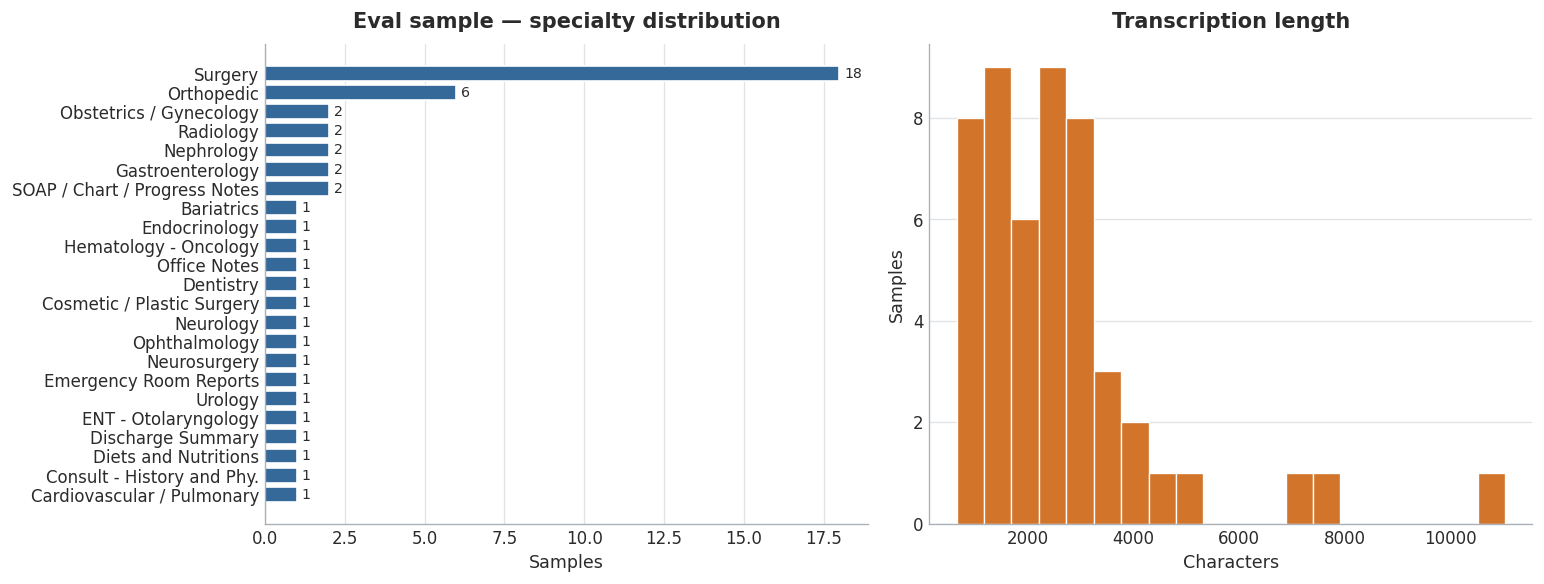

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

spec_counts = samples_df["medical_specialty"].value_counts()
axes[0].barh(spec_counts.index, spec_counts.values, color=ACCENT, edgecolor="white", height=0.78)
axes[0].invert_yaxis()
axes[0].set_title("Eval sample — specialty distribution")
axes[0].set_xlabel("Samples")
for y, v in enumerate(spec_counts.values):
    axes[0].text(v + 0.15, y, str(v), va="center", fontsize=8.5, color="#2B2B2B")
style_axes(axes[0])
axes[0].grid(axis="x", alpha=0.7); axes[0].grid(axis="y", visible=False)

axes[1].hist(samples_df["trans_len"], bins=20, color=ACCENT_WARM, edgecolor="white", linewidth=0.8)
axes[1].set_title("Transcription length")
axes[1].set_xlabel("Characters"); axes[1].set_ylabel("Samples")
style_axes(axes[1])

fig.tight_layout(); plt.show()

## 3. Per-config record loading

In [35]:
def load_jsonl_from_run(run_id: str) -> pd.DataFrame:
    local = client.download_artifacts(run_id, "records")
    jsonl_files = list(Path(local).glob("*.jsonl"))
    assert len(jsonl_files) == 1, jsonl_files
    with open(jsonl_files[0]) as f:
        return pd.DataFrame([json.loads(l) for l in f if l.strip()])

per_config = {name: load_jsonl_from_run(run.info.run_id) for name, run in children.items()}
for name, df in per_config.items():
    print(f"{name}: {len(df)} rows | abstained={df['abstained'].sum()} | errors={df['error'].notna().sum()}")

D_finetuned_rag: 50 rows | abstained=0 | errors=0
B_finetuned: 50 rows | abstained=0 | errors=0
C_base_rag: 50 rows | abstained=0 | errors=0
A_base: 50 rows | abstained=0 | errors=0


## 4. Side-by-side response comparison

Pick 5–10 sample indices and render a markdown table for qualitative review.

In [36]:
from IPython.display import Markdown

show_idxs = sorted(per_config["A_base"]["sample_idx"].sample(5, random_state=0).tolist())

def truncate(s, n=400):
    if s is None:
        return "_(abstained / error)_"
    return (s[:n] + "…") if len(s) > n else s

lines = ["| idx | specialty | A | B | C | D | ground_truth |", "|---|---|---|---|---|---|---|"]
for idx in show_idxs:
    row = {n: per_config[n].loc[per_config[n]["sample_idx"] == idx].iloc[0] for n in CONFIG_ORDER}
    spec = row["A_base"]["medical_specialty"]
    gt = row["A_base"]["ground_truth_response"]
    lines.append(
        f"| {idx} | {spec} | {truncate(row['A_base']['response'])} | {truncate(row['B_finetuned']['response'])} | "
        f"{truncate(row['C_base_rag']['response'])} | {truncate(row['D_finetuned_rag']['response'])} | {truncate(gt)} |"
    )
Markdown("\n".join(lines))

| idx | specialty | A | B | C | D | ground_truth |
|---|---|---|---|---|---|---|
| 4 | Surgery | The retrieved context is off-topic or insufficient for this clinical case. The provided documents address surgical repair of Mohs resection defects in the eyelid area, including the use of tarsoconjunctival pedicle flaps and primary approximation techniques. No evidence-based recommendation can be made from the provided documents. | 1. Recommendation or finding: There are no evidence-based recommendations provided in the retrieved context for the management of Mohs resection defects of the eyelid and canthal region.

2. Evidence basis: The retrieved documents do not contain any peer-reviewed clinical evidence or study data regarding surgical repair techniques for Mohs resection defects of the eyelid and canthal region.

3. Un… | 1. Recommendation or finding:
- For patients with lower eyelid retraction following inferior rectus muscle recession, cutaneous lower eyelid retractor release (CLERR) is recommended to virtually eliminate lower eyelid retraction and avoid inferior scleral show and new dry eye symptoms. (PMID: 39393423)
- For periocular reconstruction following Mohs micrographic or surgical excision of cutaneous ma… | 1. Recommendation or finding (with PMID citations)
- For lateral canthal defects following Mohs resection, primary approximation to the lateral canthal tendon remnant is a recommended repair technique to restore canthal stability (PMID: 29040033).
- When performing lower eyelid margin closure, a double continuous suture pattern is a simple and effective method to achieve accurate and secure wound … | 1. Recommendation or finding: Periocular reconstruction following Mohs excision of cutaneous malignancy can be effectively managed using dermal regeneration templates, full-thickness or split-thickness skin grafts, or adjacent tissue transfer. Preoperative counseling should explicitly address the significant risk of cicatricial eyelid malposition, which occurred in a majority of reported cases. (P… |
| 22 | SOAP / Chart / Progress Notes | The retrieved context is off-topic or insufficient for this clinical case. The provided documents address a patient's clinical presentation and treatment plan for suspected prostate cancer, including physical examination, imaging, laboratory, and pathology results. No evidence-based recommendation can be made from the provided documents. | 1. Recommendation or finding: External beam radiation therapy (EBRT) to the pelvis is an evidence-based treatment for locally advanced prostate cancer with regional lymph node metastasis.
2. Evidence basis: The recommendation is derived from the clinical presentation and treatment plan described in the patient note, which outlines EBRT as the initiated therapy following a diagnosis of locally adva… | 1. Recommendation or finding: 
- External beam radiation therapy is a recommended treatment for this patient's clinical presentation of prostatic malignancy with extracapsular extension and probable regional node metastasis.
- Radical prostatectomy may not be recommended due to the presence of extracapsular extension and regional node metastasis.

2. Evidence basis: 
- The evidence from [3] PMID: … | 1. Recommendation or finding (with PMID citations)
- Radical prostatectomy is a treatment option for prostate cancer, particularly when combined with neoadjuvant therapies such as external beam radiation therapy and chemotherapy (PMID: 30369229).
- Wide resection techniques during robot-assisted radical prostatectomy may be utilized to optimize oncological and functional outcomes in very high-risk… | 1. Recommendation or finding: For locally advanced or very high-risk prostate cancer with extracapsular extension and pelvic lymph node metastasis, evidence supports the use of external beam radiation therapy (EBRT) to the pelvis, frequently integrated with chemotherapy and/or hormonal therapy as part of a multimodality approach. Surgical intervention, such as radical prostatectomy with wide resec… |
| 24 | Gastroenterology | The retrieved context is off-topic or insufficient for this clinical case. The provided documents address the procedure and findings of an Endoscopic Retrograde Cholangiopancreatography (ERCP) with brush cytology and biopsy, but no evidence-based recommendations can be made from the provided documents. | 1. Recommendation or finding (with PMID citations)
2. Evidence basis (study type if inferable from the abstract)
3. Uncertainty or gaps in the retrieved evidence

1. Recommendation or finding: No evidence-based treatment recommendations can be made from the provided documents, as they do not address the clinical management of chronic pancreatitis, ampullary abnormalities, or endoscopic retrograde … | 1. Recommendation or finding: 
- Proceed with MRCP to better delineate pancreatic ductal anatomy (PMID: 40518920).
- Consider using needle-knife fistulotomy as a primary approach for difficult biliary cannulation (PMID: 41801579).
- Avoid complications of ERCP by using prophylactic strategies, such as rectal NSAIDs, aggressive intravenous fluid hydration, and pancreatic duct stents (PMID: 40402845… | 1. Recommendation or finding (with PMID citations)
- To reduce the risk of post-ERCP pancreatitis and improve biliary cannulation success, endoscopists should utilize pre- and intra-procedural prophylactic strategies, including aggressive intravenous fluid hydration, rectal nonsteroidal anti-inflammatory drugs (e.g., indomethacin), and pancreatic duct stents (PMID: 40402845).
- For difficult bilia… | 1. Recommendation or finding: For an ampullary lesion with adenomatous-appearing mucosa, complete resection is recommended due to premalignant potential. Treatment options include endoscopic ampullectomy, surgical ampullectomy, or pancreatoduodenectomy. If endoscopic resection is not amenable, a totally laparoscopic transduodenal ampullectomy is a recommended minimally invasive surgical alternativ… |
| 57 | Orthopedic | The retrieved context is off-topic or insufficient for this clinical case. The provided documents address a patient's MRI findings and clinical presentation of a 53-year-old female with left knee pain being evaluated for an ACL tear, but no evidence-based recommendations can be made from the provided documents. | 1. Recommendation or finding: For a patient with a near-complete tear of the anterior cruciate ligament (ACL) and medial collateral ligament (MCL) sprain, evidence-based treatment recommendations are limited in this retrieved context. However, ACL injuries are commonly managed with surgical reconstruction, while MCL sprains are often treated conservatively with bracing, physical therapy, and nonst… | 1. Recommendation or finding: 
- Early ACL reconstruction (ACLR) may be associated with better patient-reported outcomes at 11 years after an ACL injury compared to ACL continuity on 5-year MRI (PMID: 40387842).
- The addition of a centralization suture in transtibial root repair may reduce postoperative medial meniscal extrusion in patients with type 2 posterior medial meniscus root (PMMR) tears … | 1. Recommendation or finding (with PMID citations)
- For patients with anterior cruciate ligament (ACL) injuries, early surgical reconstruction combined with meniscus repair is recommended to restore knee stability and prevent long-term cartilage degeneration and osteoarthritis (PMID: 41349859).
- Magnetic resonance imaging (MRI) is the primary diagnostic modality for evaluating ACL and meniscus i… | 1. Recommendation or finding: For the near-complete to complete ACL femoral attachment tear, early or delayed anterior cruciate ligament reconstruction (ACLR) is recommended over nonoperative management to improve long-term patient-reported outcomes. For the concurrent MCL and lateral ligament complex sprains, mild injuries may be managed conservatively, whereas high-grade tears or those causing r… |
| 85 | Radiology | The retrieved context is off-topic or insufficient for this clinical case. The provided documents address the diagnostic findings and clinical presentation of a patient with dysphagia, specifically highlighting penetration with thin liquids and weakness in the oral phase of deglutition. No evidence-based recommendation can be made from the provided documents. | The retrieved context is off-topic or insufficient for this clinical case. The provided documents address the diagnostic accuracy and radiographic findings of penetration versus aspiration during modified barium swallow studies. No evidence-based recommendation can be made from the provided documents. | 1. Recommendation or finding:
- Thickened liquids may help improve swallowing safety for neurogenic dysphagia, but the evidence remains weak and further randomized controlled trials (RCTs) are needed to validate the clinical efficacy of thickeners (PMID: 40693645).
- Outpatient swallowing therapy, specifically a progressive swallowing exercise regimen based on the Systematic Exercise for Treatment… | 1. Recommendation or finding (with PMID citations)
- Thickened liquids may be considered to improve swallowing safety and reduce aspiration risk in patients with neurogenic dysphagia, though evidence remains weak and primarily derived from non-randomized controlled trials (PMID: 40693645).
- Outpatient exercise-based swallowing therapy can improve swallowing physiology, safety, and efficiency, and… | 1. Recommendation or finding (with PMID citations)
- Structured outpatient swallowing therapy is recommended to improve swallowing physiology, safety, and oral impairment scores, which may facilitate the relaxation of diet consistency restrictions (PMID: 40148536).
- While thickened liquids are frequently utilized to mitigate aspiration risk, they do not significantly reduce penetration events and… |

## 5. Hallucinated PMIDs

Once the FT GGUF repetition collapse was fixed (16-bit merge, see DECISIONS.md 2026-06-15),
PMID hallucination is **no longer the headline finding** — it is near-zero everywhere
(B≈0.04, D≈0.02). The discriminating story moved to the citation-behaviour metrics in
§6b (PMID vs bracket vs placeholder citation, grounding precision). See DECISIONS.md
2026-06-16.

`hallucinated_pmids_rate` was also **redefined** (2026-06-16): it is now the *fraction of
answers carrying ≥1 hallucinated PMID*, not the old per-sample mean (which lives in
`hallucinated_pmids_per_sample_mean`).

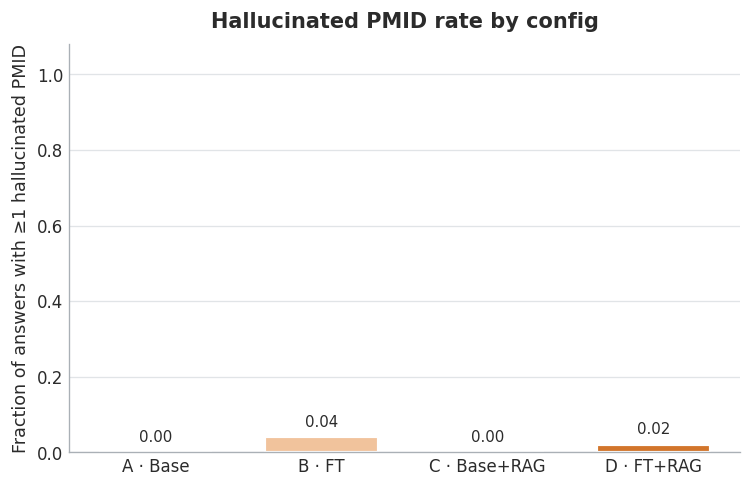

{'A_base': 0.0,
 'B_finetuned': 0.04,
 'C_base_rag': 0.0,
 'D_finetuned_rag': 0.02}

In [37]:
rates = {n: children[n].data.metrics.get("hallucinated_pmids_rate", math.nan) for n in CONFIG_ORDER}
fig, ax = plt.subplots(figsize=(6.4, 4.2))
grouped_bar(
    ax, CONFIG_ORDER, [rates[n] for n in CONFIG_ORDER],
    ylabel="Fraction of answers with ≥1 hallucinated PMID",
    title="Hallucinated PMID rate by config",
)
fig.tight_layout(); plt.show()
rates

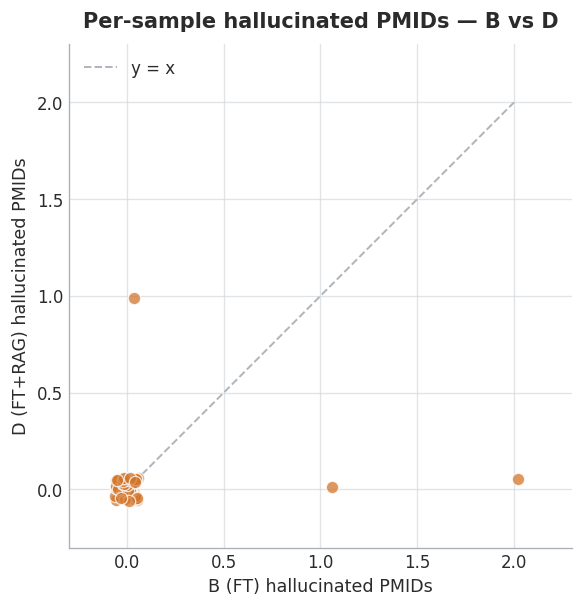

In [38]:
# Per-sample B vs D scatter: x = # hallucinated PMIDs by B, y = by D
b = per_config["B_finetuned"].set_index("sample_idx")["hallucinated_pmids"].apply(len)
d = per_config["D_finetuned_rag"].set_index("sample_idx")["hallucinated_pmids"].apply(len)
joined = pd.concat([b.rename("B"), d.rename("D")], axis=1).fillna(0)
lim = max(joined.max().max(), 1)

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.plot([0, lim], [0, lim], color="#B0B6BC", linestyle="--", linewidth=1.2, zorder=1, label="y = x")
# Jitter overlapping integer points so density is visible.
rng = np.random.default_rng(0)
jx = joined["B"] + rng.uniform(-0.06, 0.06, len(joined))
jy = joined["D"] + rng.uniform(-0.06, 0.06, len(joined))
ax.scatter(jx, jy, s=55, alpha=0.75, color=CONFIG_COLORS["D_finetuned_rag"],
           edgecolor="white", linewidth=0.8, zorder=2)
ax.set_xlim(-0.3, lim + 0.3); ax.set_ylim(-0.3, lim + 0.3)
ax.set_aspect("equal")
ax.set_xlabel("B (FT) hallucinated PMIDs"); ax.set_ylabel("D (FT+RAG) hallucinated PMIDs")
ax.set_title("Per-sample hallucinated PMIDs — B vs D")
ax.legend(loc="upper left")
style_axes(ax); ax.grid(axis="x", alpha=0.7)
fig.tight_layout(); plt.show()

## 6. Format adherence

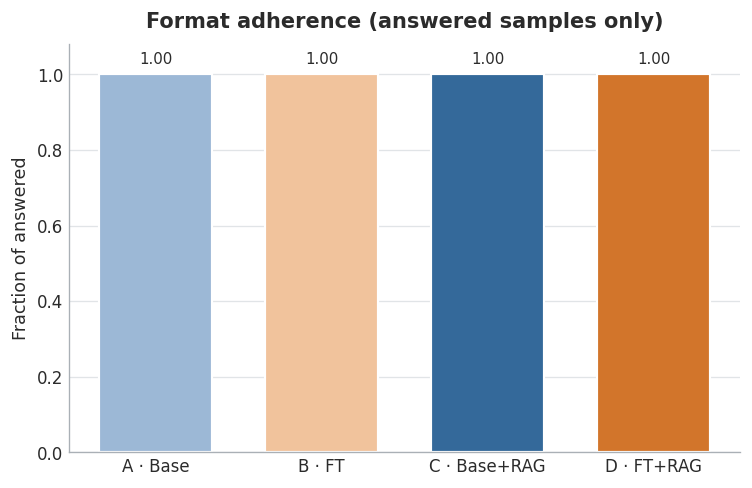

{'A_base': 1.0, 'B_finetuned': 1.0, 'C_base_rag': 1.0, 'D_finetuned_rag': 1.0}

In [39]:
vals = {n: children[n].data.metrics.get("format_adherence_among_answered", math.nan) for n in CONFIG_ORDER}
fig, ax = plt.subplots(figsize=(6.4, 4.2))
grouped_bar(
    ax, CONFIG_ORDER, [vals[n] for n in CONFIG_ORDER],
    ylabel="Fraction of answered",
    title="Format adherence (answered samples only)",
)
fig.tight_layout(); plt.show()
vals

## 6b. Citation-behaviour metrics — the discriminating finding

Judge-free metrics computed deterministically from the runner JSONL (DECISIONS.md 2026-06-16).
These cover the axis RAGAS cannot and carry the main Cap. 6 citation/format story:

- **RAG turns citation on** (A→C, B→D): `pmid_citation_rate` jumps from ~0 to 0.84/0.98.
- **Fine-tuning fixes the *format***: it eliminates the base model's `[1]`-style bracket refs
  (`bracket_citation_rate` C 0.30 → D 0.00) and drives PMID citation to 0.98.
- **No-evidence contrast**: base *refuses* (A `no_citation_rate`=1.0) while FT-only *fabricates*
  the literal `(PMID: XXXXXXXX)` placeholder it saw in training (B `placeholder_citation_rate`≈0.60)
  — an OOD input (`evidence=(none)`) the model never trained on.
- **Grounding**: every cited PMID in the RAG configs is in-set (`citation_grounding_precision`=1.0).

,pmid_citation_rate,bracket_citation_rate,placeholder_citation_rate,no_citation_rate,citation_grounding_precision,pmid_citations_per_answered_mean
A_base,0.00,0.0,0.0,1.00,NaN,0.00
B_finetuned,0.04,0.0,0.6,0.36,NaN,0.12
C_base_rag,0.84,0.3,0.0,0.00,1.0,5.38
D_finetuned_rag,0.98,0.0,0.0,0.02,1.0,5.04


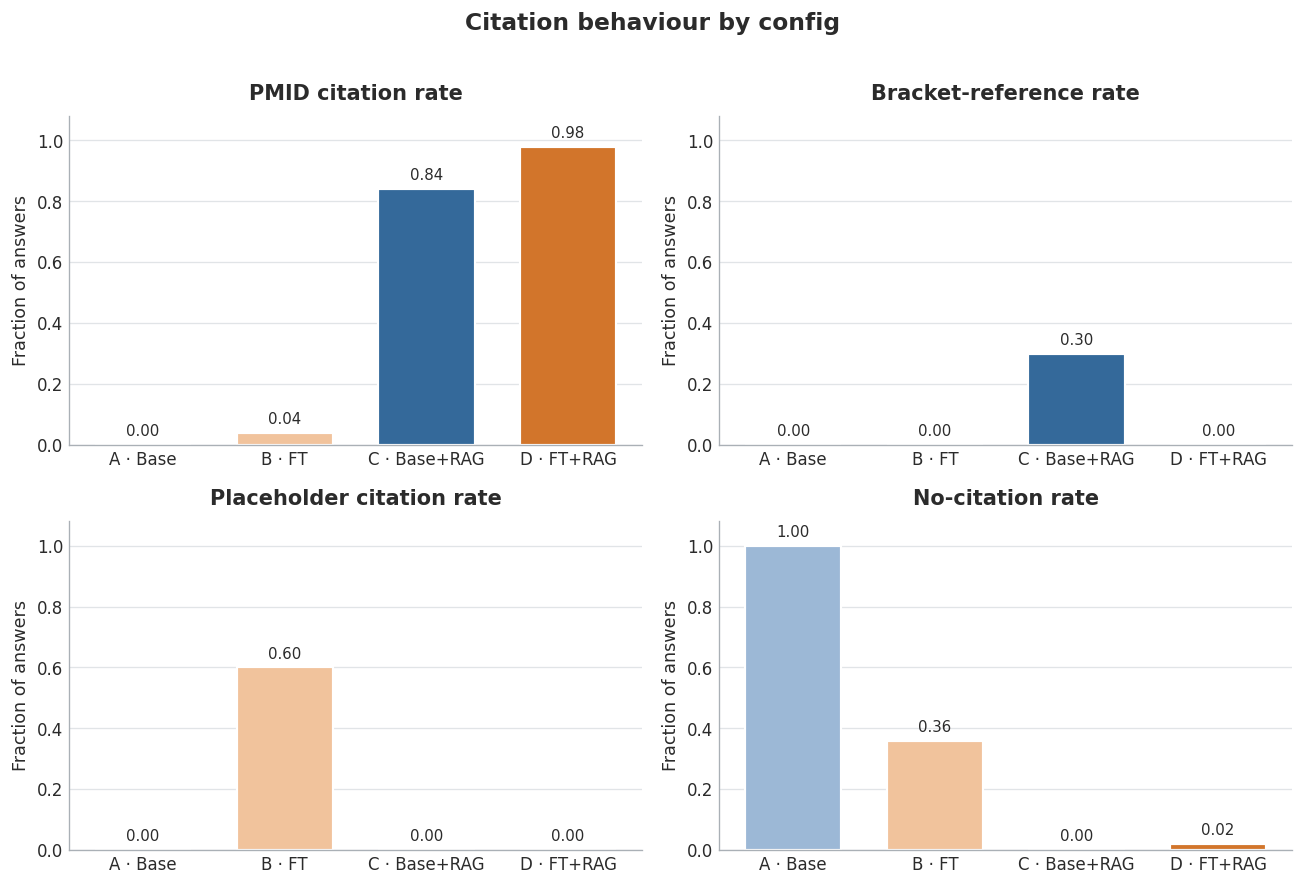

citation_grounding_precision: {'A_base': 'NaN (no-RAG)', 'B_finetuned': 'NaN (no-RAG)', 'C_base_rag': 1.0, 'D_finetuned_rag': 1.0}


In [40]:
# Citation-behaviour metrics (judge-free, computed from JSONL). Rates are over
# answered records. citation_grounding_precision is NaN for no-RAG configs A/B.
CITATION_METRICS = [
    "pmid_citation_rate",
    "bracket_citation_rate",
    "placeholder_citation_rate",
    "no_citation_rate",
    "citation_grounding_precision",
    "pmid_citations_per_answered_mean",
]
cite_df = pd.DataFrame(
    {m: {n: children[n].data.metrics.get(m, math.nan) for n in CONFIG_ORDER} for m in CITATION_METRICS}
).loc[CONFIG_ORDER]
display(cite_df.round(3))

# The four rate metrics on a shared 0–1 axis (the FT-format + RAG-grounding story).
rate_metrics = ["pmid_citation_rate", "bracket_citation_rate", "placeholder_citation_rate", "no_citation_rate"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
for ax, metric in zip(axes.flat, rate_metrics):
    vals = [children[n].data.metrics.get(metric, math.nan) for n in CONFIG_ORDER]
    grouped_bar(ax, CONFIG_ORDER, vals, ylabel="Fraction of answers", title=metric_title(metric))
fig.suptitle("Citation behaviour by config", fontsize=14, fontweight="semibold")
fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()

# Grounding precision (RAG configs only): fraction of cited PMIDs that were retrieved.
gp = {n: children[n].data.metrics.get("citation_grounding_precision", math.nan) for n in CONFIG_ORDER}
print("citation_grounding_precision:", {k: round(v, 3) if v == v else "NaN (no-RAG)" for k, v in gp.items()})

## 7. RAGAS metrics with 95% CIs

`faithfulness`, `context_precision`, and `context_recall` need retrieved contexts, so they
are only computed for the RAG configs C/D (NaN bars for A/B). `answer_relevancy` runs for all
four.

**Config A `answer_relevancy` ≈ 0.00 is expected, not a bug:** given the no-RAG prompt
(`evidence=(none)`), the base model emits the no-evidence refusal template on every sample, and
a refusal scores ~0 on answer_relevancy by construction. This is the clean *base-refuses /
FT-only-fabricates* contrast (cf. §6b). See DECISIONS.md 2026-06-16 / STATUS.md.

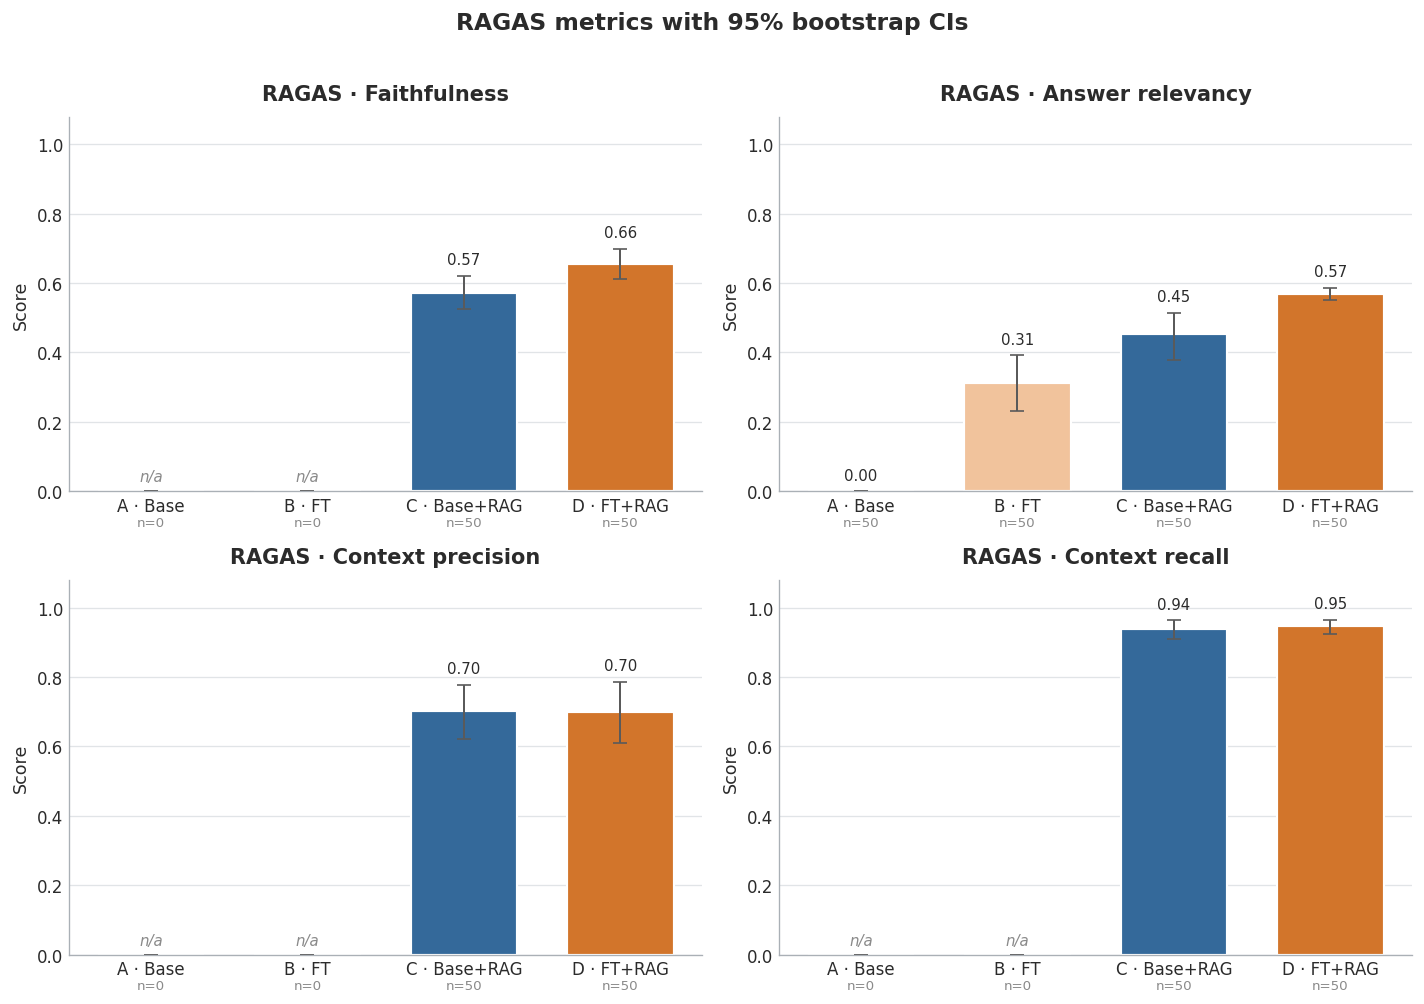

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))
for ax, metric in zip(axes.flat, ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]):
    means = [children[n].data.metrics.get(f"{metric}_mean", math.nan) for n in CONFIG_ORDER]
    lows = [children[n].data.metrics.get(f"{metric}_ci_low", math.nan) for n in CONFIG_ORDER]
    highs = [children[n].data.metrics.get(f"{metric}_ci_high", math.nan) for n in CONFIG_ORDER]
    n_used = [int(children[n].data.metrics.get(f"{metric}_n", 0)) for n in CONFIG_ORDER]
    bars = grouped_bar(
        ax, CONFIG_ORDER, means, ylabel="Score", title=f"RAGAS · {metric_title(metric)}",
        ci_low=lows, ci_high=highs, annotate=False,
    )
    # Annotate mean value above the CI whisker, with the per-config n underneath the axis.
    for i, (bar, m, hi, nn) in enumerate(zip(bars, means, highs, n_used)):
        x = bar.get_x() + bar.get_width() / 2
        if m == m:  # not NaN
            top = hi if hi == hi else m
            ax.text(x, top + 0.025, f"{m:.2f}", ha="center", va="bottom", fontsize=9)
        else:
            ax.text(x, 0.02, "n/a", ha="center", va="bottom", fontsize=9, color="#8A8A8A", style="italic")
        ax.text(x, -0.07, f"n={nn}", ha="center", va="top", fontsize=8, color="#8A8A8A")
fig.suptitle("RAGAS metrics with 95% bootstrap CIs", fontsize=14, fontweight="semibold")
fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()

## 8. Abstention analysis (C and D only)

In [42]:
for name in ("C_base_rag", "D_finetuned_rag"):
    df = per_config[name]
    abst = df[df["abstained"]]
    print(f"{name}: {len(abst)}/{len(df)} abstained ({len(abst)/len(df):.1%})")
    for _, row in abst.head(2).iterrows():
        print(f"  idx={row['sample_idx']} | specialty={row['medical_specialty']} | trans[:120]={row['transcription'][:120]!r}")

C_base_rag: 0/50 abstained (0.0%)
D_finetuned_rag: 0/50 abstained (0.0%)


## 9. Cross-config deltas (from rollup run)

In [43]:
if rollup is None:
    print("No rollup run yet — run scripts/run_evaluation_rollup.py first.")
else:
    deltas = {k: v for k, v in rollup.data.metrics.items() if k.startswith("D_minus_")}
    x = pd.Series(deltas).to_frame("delta")
    display(x)



,delta
D_minus_B_hallucinated_pmids_rate,-0.020000
D_minus_C_faithfulness_mean,0.083197
D_minus_B_format_adherence,0.000000
D_minus_C_abstention_rate,0.000000
D_minus_C_citation_grounding_precision,0.000000


## 10. Failure case review

In [44]:
for name, df in per_config.items():
    errs = df[df["error"].notna()]
    if not errs.empty:
        print(f"=== {name}: {len(errs)} errors ===")
        print(errs[["sample_idx", "medical_specialty", "error"]].to_string(index=False))

## 11. Cap. 6 narrative scratch

Free-form markdown space for drafting the thesis evaluation chapter against the numbers above.

- Headline claim: ___
- Key delta evidence: ___
- Caveats (ContextRecall ceiling, abstention as outcome): ___